Размер датасета: (67698, 7)
Типы данных:
DATE_TIME       object
PLANT_ID         int64
SOURCE_KEY      object
DC_POWER       float64
AC_POWER       float64
DAILY_YIELD    float64
TOTAL_YIELD    float64
dtype: object
Пропуски по столбцам:
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
Количество уникальных инверторов: 22
Количество уникальных PLANT_ID: 1
Минимальная дата: 2020-05-15 00:00:00
Максимальная дата: 2020-06-17 23:45:00
Период наблюдений (дней): 33
Нулевые значения AC_POWER: 35662
Доля нулевых AC_POWER: 52.68%
Нулевые значения DC_POWER: 35662
Доля нулевых DC_POWER: 52.68%


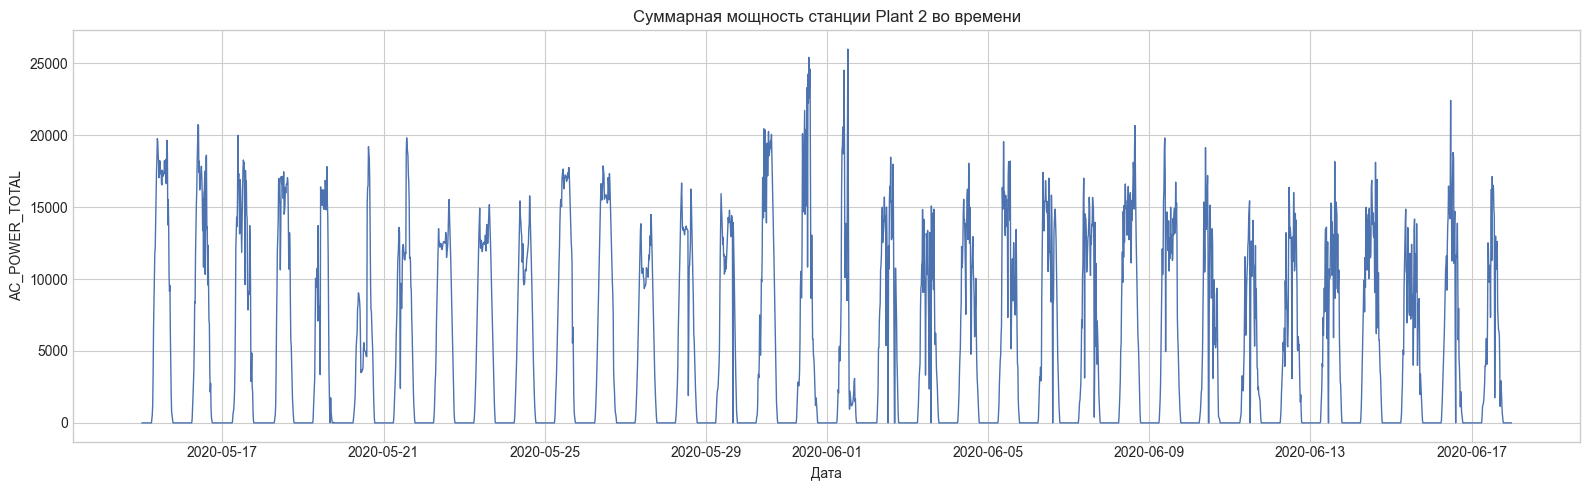

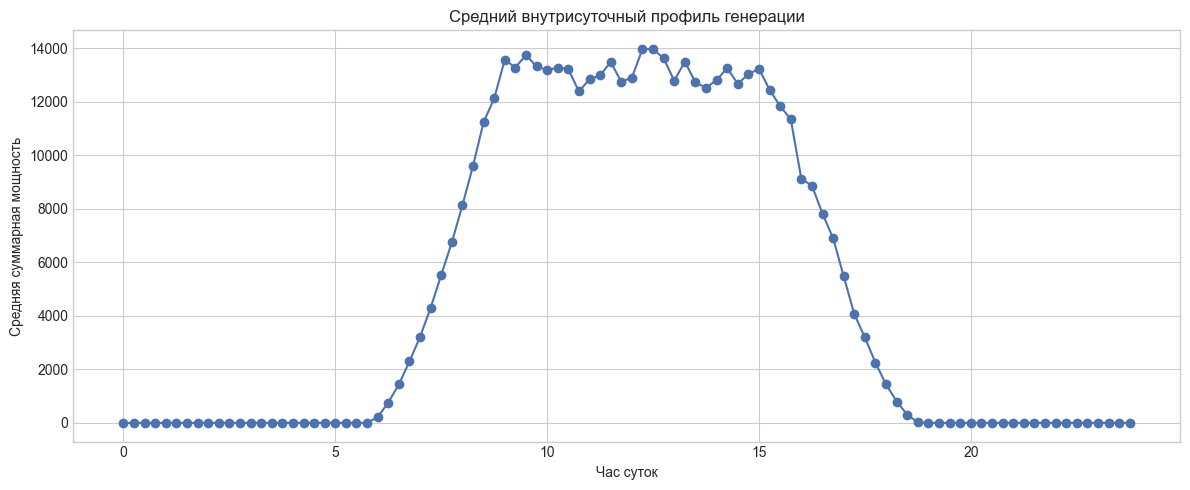

       AC_POWER_TOTAL
count       34.000000
mean    480412.535601
std      75956.087290
min     335847.822161
25%     434032.583175
50%     486394.528243
75%     536188.367738
max     651437.736667


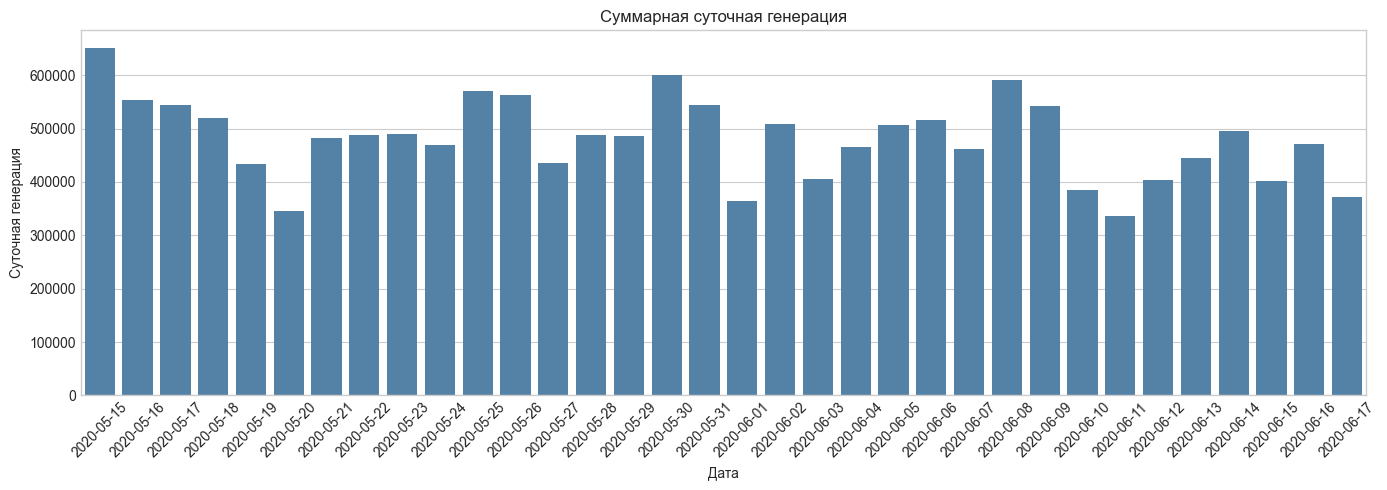

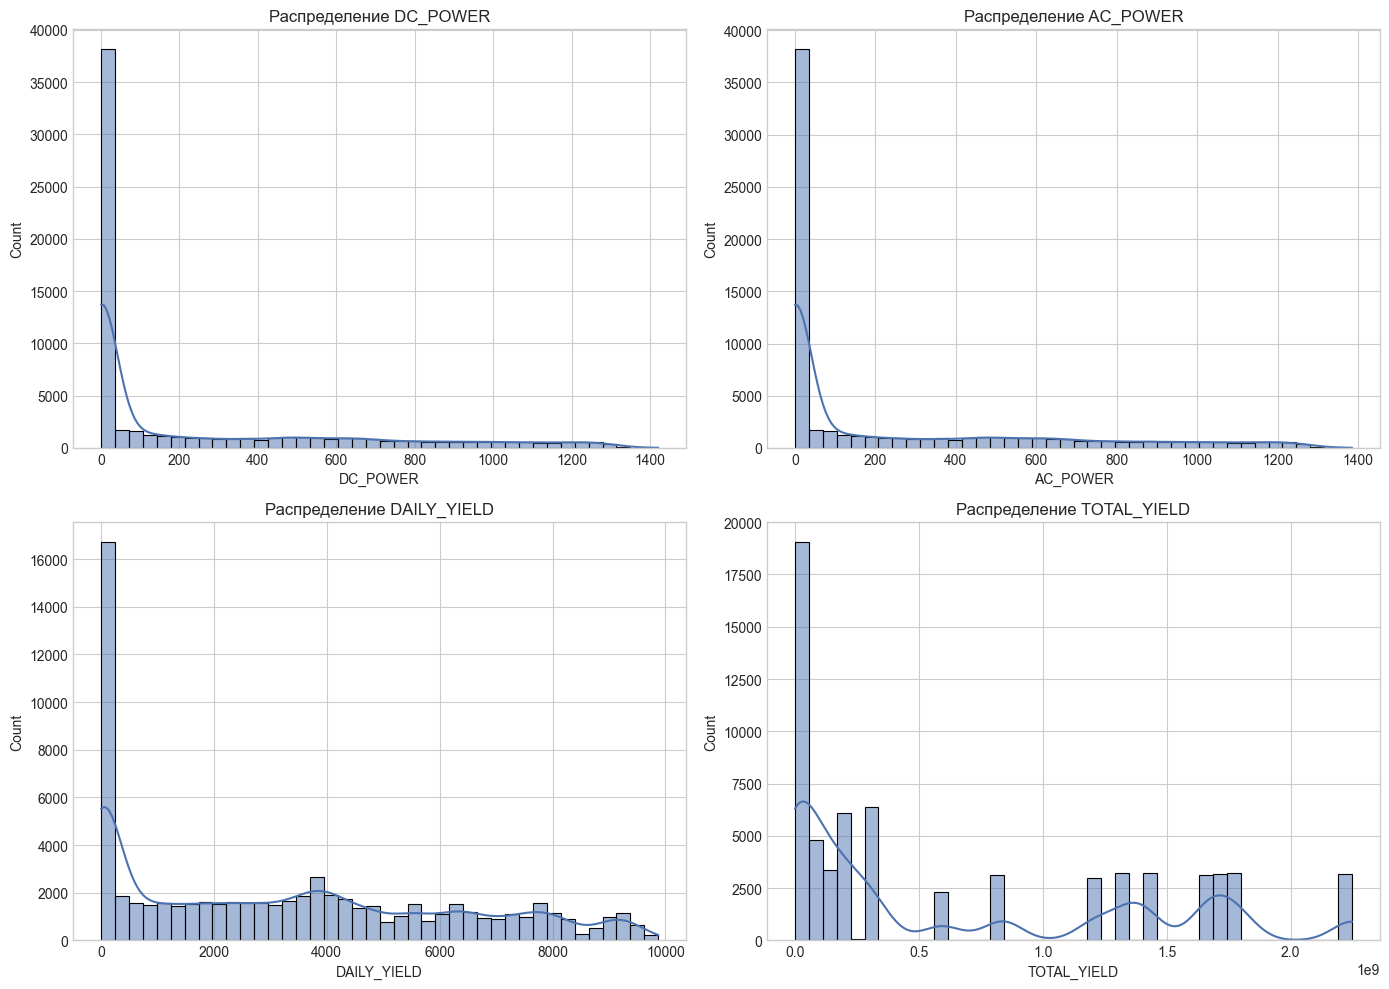

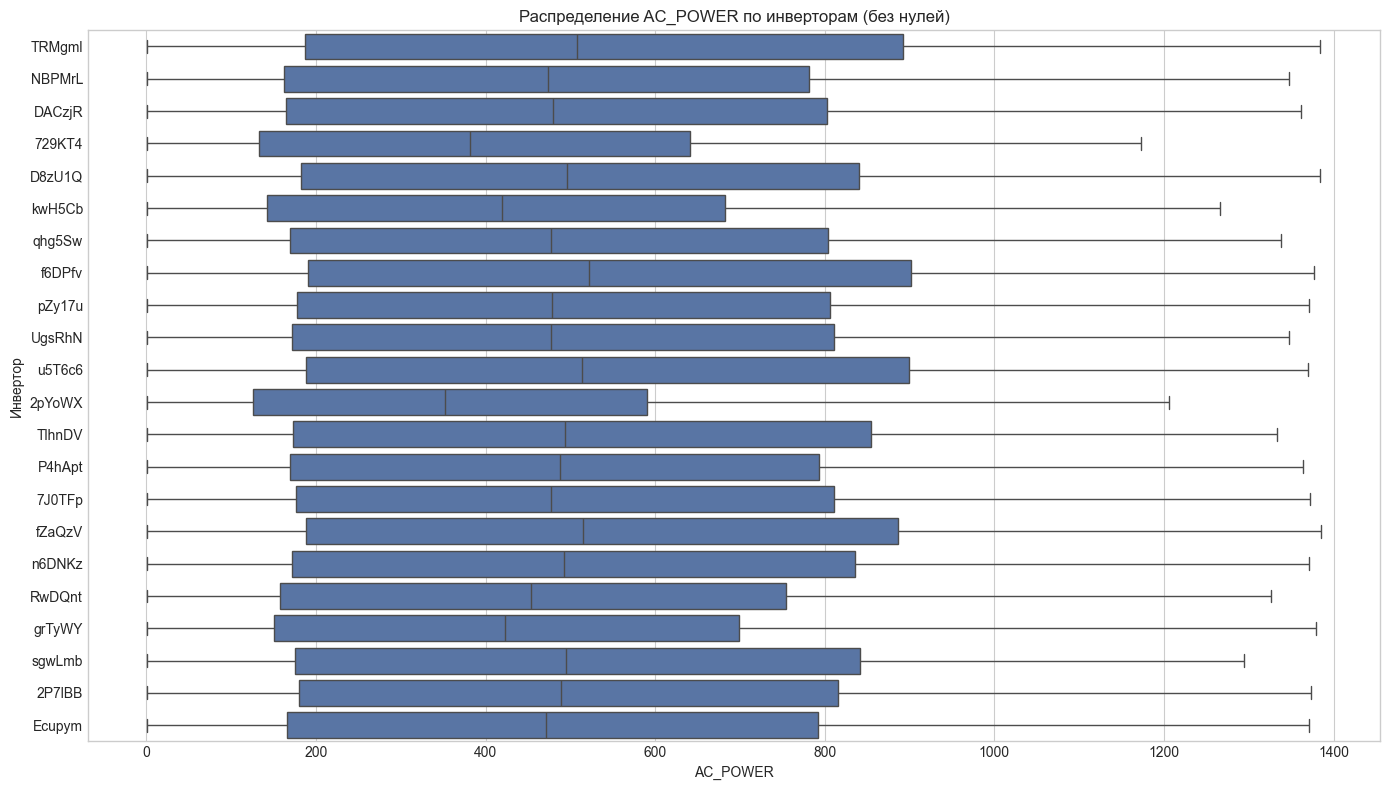

ADF statistic: -14.12945496624416
p-value: 2.3476777416778458e-26
Used lag: 29
Number of observations: 3234
Critical values: {'1%': -3.4323736543200587, '5%': -2.862434128955772, '10%': -2.5672459643116254}
Вывод: ряд можно считать стационарным по критерию ADF.


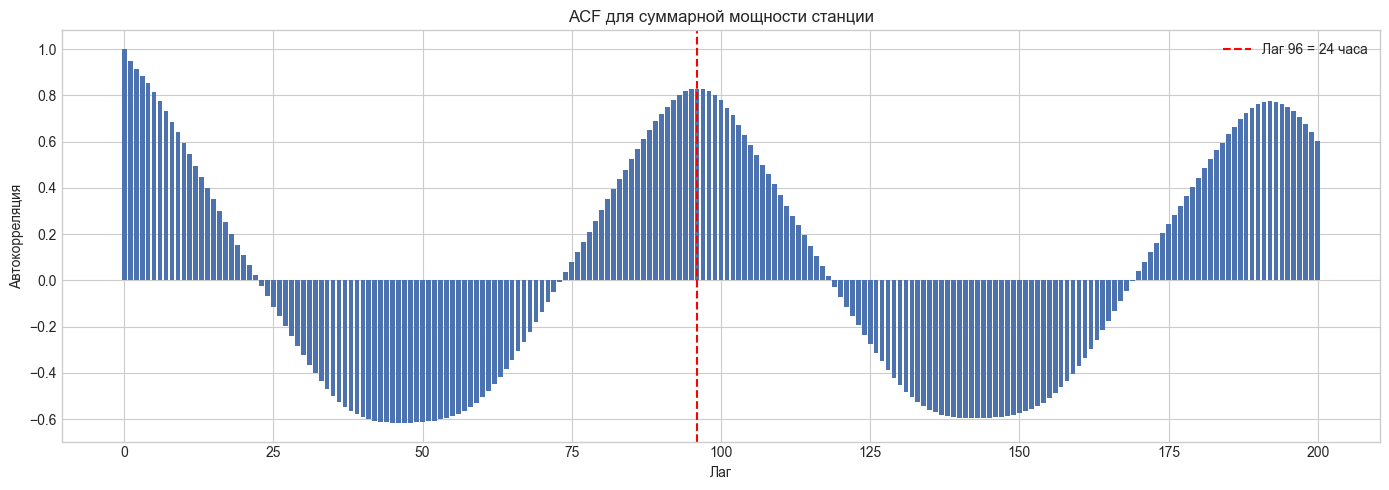

ADF после сезонного дифференцирования (lag=96):
ADF statistic: -12.933571900580121
p-value: 3.657422777358851e-24
Файлы сохранены:
- output/plant2_prepared_timeseries.csv
- output/plant2_daily_generation.csv


In [1]:

import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)


file_path = 'Plant_2_Generation_Data.csv'
df = pd.read_csv(file_path)

print('Размер датасета:', df.shape)
df.head()


print('Типы данных:')
print(df.dtypes)

print('Пропуски по столбцам:')
print(df.isnull().sum())

print('Количество уникальных инверторов:', df['SOURCE_KEY'].nunique())
print('Количество уникальных PLANT_ID:', df['PLANT_ID'].nunique())


df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df = df.sort_values(['DATE_TIME', 'SOURCE_KEY']).reset_index(drop=True)

print('Минимальная дата:', df['DATE_TIME'].min())
print('Максимальная дата:', df['DATE_TIME'].max())
print('Период наблюдений (дней):', (df['DATE_TIME'].max() - df['DATE_TIME'].min()).days)


df.describe(include='all')

zero_ac = (df['AC_POWER'] == 0).sum()
zero_dc = (df['DC_POWER'] == 0).sum()

print('Нулевые значения AC_POWER:', zero_ac)
print('Доля нулевых AC_POWER: {:.2f}%'.format(100 * zero_ac / len(df)))
print('Нулевые значения DC_POWER:', zero_dc)
print('Доля нулевых DC_POWER: {:.2f}%'.format(100 * zero_dc / len(df)))

plant_ts = (
    df.groupby('DATE_TIME', as_index=False)['AC_POWER']
      .sum()
      .rename(columns={'AC_POWER': 'AC_POWER_TOTAL'})
)

plant_ts = plant_ts.set_index('DATE_TIME').asfreq('15min', fill_value=0)
plant_ts.head()

plt.figure(figsize=(16, 5))
plt.plot(plant_ts.index, plant_ts['AC_POWER_TOTAL'], linewidth=1)
plt.title('Суммарная мощность станции Plant 2 во времени')
plt.xlabel('Дата')
plt.ylabel('AC_POWER_TOTAL')
plt.tight_layout()
plt.show()


profile_df = plant_ts.reset_index().copy()
profile_df['hour'] = profile_df['DATE_TIME'].dt.hour + profile_df['DATE_TIME'].dt.minute / 60
mean_daily_profile = profile_df.groupby('hour', as_index=False)['AC_POWER_TOTAL'].mean()

plt.figure(figsize=(12, 5))
plt.plot(mean_daily_profile['hour'], mean_daily_profile['AC_POWER_TOTAL'], marker='o')
plt.title('Средний внутрисуточный профиль генерации')
plt.xlabel('Час суток')
plt.ylabel('Средняя суммарная мощность')
plt.tight_layout()
plt.show()

daily_generation = (
    plant_ts.reset_index()
            .assign(date=lambda x: x['DATE_TIME'].dt.date)
            .groupby('date', as_index=False)['AC_POWER_TOTAL']
            .sum()
)

print(daily_generation.describe())

a = plt.figure(figsize=(14, 5))
sns.barplot(data=daily_generation, x='date', y='AC_POWER_TOTAL', color='steelblue')
plt.title('Суммарная суточная генерация')
plt.xlabel('Дата')
plt.ylabel('Суточная генерация')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


num_cols = ['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()

df_nonzero = df[df['AC_POWER'] > 0].copy()
df_nonzero['INV_SHORT'] = df_nonzero['SOURCE_KEY'].str[-6:]

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_nonzero, y='INV_SHORT', x='AC_POWER')
plt.title('Распределение AC_POWER по инверторам (без нулей)')
plt.xlabel('AC_POWER')
plt.ylabel('Инвертор')
plt.tight_layout()
plt.show()

series = plant_ts['AC_POWER_TOTAL']
adf_stat, p_value, used_lag, nobs, critical_values, icbest = adfuller(series, autolag='AIC')

print('ADF statistic:', adf_stat)
print('p-value:', p_value)
print('Used lag:', used_lag)
print('Number of observations:', nobs)
print('Critical values:', critical_values)

if p_value < 0.05:
    print('Вывод: ряд можно считать стационарным по критерию ADF.')
else:
    print('Вывод: ряд нестационарен, желательно выполнить преобразование.')


acf_values = acf(series, nlags=200, fft=True)

plt.figure(figsize=(14, 5))
plt.bar(range(len(acf_values)), acf_values, width=0.8)
plt.axvline(x=96, color='red', linestyle='--', label='Лаг 96 = 24 часа')
plt.title('ACF для суммарной мощности станции')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.legend()
plt.tight_layout()
plt.show()

series_diff = series.diff(96).dropna()

adf_stat_diff, p_value_diff, *_ = adfuller(series_diff, autolag='AIC')
print('ADF после сезонного дифференцирования (lag=96):')
print('ADF statistic:', adf_stat_diff)
print('p-value:', p_value_diff)


os.makedirs('output', exist_ok=True)

prepared_ts = plant_ts.reset_index().copy()
prepared_ts.to_csv('output/plant2_prepared_timeseries.csv', index=False)
daily_generation.to_csv('output/plant2_daily_generation.csv', index=False)

print('Файлы сохранены:')
print('- output/plant2_prepared_timeseries.csv')
print('- output/plant2_daily_generation.csv')


Задача  2

In [7]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")


data_path = Path("output") / "plant2_prepared_timeseries.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Файл {data_path} не найден. "
        "Сначала выполните ноутбук задачи №1 и сохраните данные."
    )

df_ts = pd.read_csv(data_path, parse_dates=["DATE_TIME"])
df_ts = df_ts.sort_values("DATE_TIME").reset_index(drop=True)

sf_df = df_ts.rename(columns={"DATE_TIME": "ds", "AC_POWER_TOTAL": "y"})
sf_df["unique_id"] = "plant2"
sf_df = sf_df[["unique_id", "ds", "y"]]

print(sf_df.head())
print(f"Всего записей: {len(sf_df)}")


freq = "15min"
steps_per_day = 96
test_days = 7
h = steps_per_day * test_days

sf_df = sf_df.sort_values("ds").reset_index(drop=True)
n_total = len(sf_df)
n_train = n_total - h

train_df = sf_df.iloc[:n_train].copy()
test_df  = sf_df.iloc[n_train:].copy()

print(f"Всего: {n_total}, Train: {len(train_df)}, Test: {len(test_df)}, h={h}")




  unique_id                  ds    y
0    plant2 2020-05-15 00:00:00  0.0
1    plant2 2020-05-15 00:15:00  0.0
2    plant2 2020-05-15 00:30:00  0.0
3    plant2 2020-05-15 00:45:00  0.0
4    plant2 2020-05-15 01:00:00  0.0
Всего записей: 3264
Всего: 3264, Train: 2592, Test: 672, h=672


Записей: 3264,  2020-05-15 00:00:00 → 2020-06-17 23:45:00
Train: 2592, Test: 672, h=672
Hold-out forecast: 3.4 сек
   index unique_id                  ds  ARIMA_manual  MSTL_ETS  SeasonalNaive    y
0      0    plant2 2020-06-11 00:00:00           0.0       0.0            0.0  0.0
1      1    plant2 2020-06-11 00:15:00           0.0       0.0            0.0  0.0
2      2    plant2 2020-06-11 00:30:00           0.0       0.0            0.0  0.0
3      3    plant2 2020-06-11 00:45:00           0.0       0.0            0.0  0.0
4      4    plant2 2020-06-11 01:00:00           0.0       0.0            0.0  0.0
Hold-out метрики:
           model     MAE    RMSE  sMAPE_day
0   ARIMA_manual  1405.0  2687.3      37.15
1       MSTL_ETS  1431.1  2726.3      36.80
2  SeasonalNaive  2038.6  3903.8      67.31


Text(0, 0.5, 'Значение')

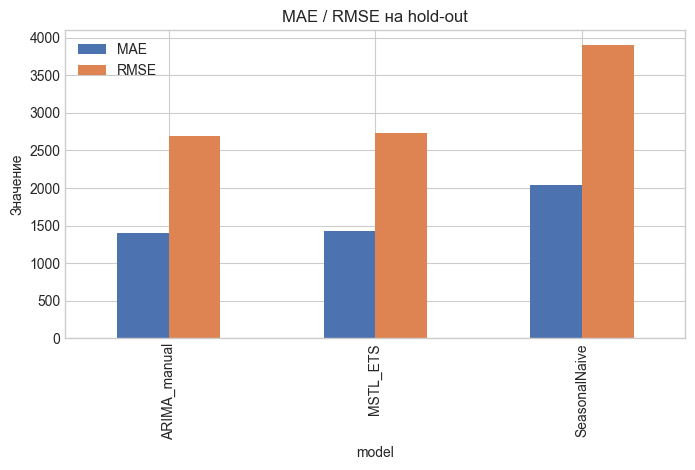

In [9]:
# %% [markdown]
# Задача №2. Оптимизированная версия: MSTL+ETS вместо AutoARIMA, встроенный CV

# %%
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, MSTL, AutoETS, SeasonalNaive
from sklearn.metrics import mean_absolute_error

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def compute_metrics(y_true, y_pred, name):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float).clip(0)
    mask = y_true > 0
    smape = np.nan
    if mask.sum() > 0:
        yt, yp = y_true[mask], y_pred[mask]
        d = np.abs(yt) + np.abs(yp)
        smape = 100 * np.mean(np.where(d > 0, 2 * np.abs(yt - yp) / d, 0.0))
    return {
        "model":     name,
        "MAE":       round(mean_absolute_error(y_true, y_pred), 1),
        "RMSE":      round(rmse(y_true, y_pred), 1),
        "sMAPE_day": round(smape, 2),
    }

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

# %% [markdown]
# 1. Загрузка данных

# %%
df_ts = pd.read_csv(
    Path("output") / "plant2_prepared_timeseries.csv",
    parse_dates=["DATE_TIME"]
)
sf_df = (df_ts
         .sort_values("DATE_TIME")
         .rename(columns={"DATE_TIME": "ds", "AC_POWER_TOTAL": "y"})
         .assign(unique_id="plant2")
         [["unique_id", "ds", "y"]]
         .reset_index(drop=True))
print(f"Записей: {len(sf_df)},  {sf_df['ds'].min()} → {sf_df['ds'].max()}")

# %% [markdown]
# 2. Train / Test split

# %%
freq          = "15min"
season_length = 96         # 96 × 15мин = 24 ч
test_days     = 7
h             = season_length * test_days   # 672

n_train   = len(sf_df) - h
train_df  = sf_df.iloc[:n_train].copy()
test_df   = sf_df.iloc[n_train:].copy()
print(f"Train: {len(train_df)}, Test: {len(test_df)}, h={h}")

# %% [markdown]
# 3. Модели (быстрые)
#
# | Модель         | Время   | Описание                              |
# |----------------|---------|---------------------------------------|
# | ARIMA_manual   | ~5 сек  | Фиксированный порядок, нет перебора   |
# | MSTL_ETS       | ~10 сек | STL-декомпозиция + ETS на остатках    |
# | SeasonalNaive  | <1 сек  | Baseline                              |
#
# AutoARIMA(season_length=96) ИСКЛЮЧЁН — перебирает 64+ моделей × 6 вызовов в backtest

# %%
models = [
    ARIMA(
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1),
        season_length=season_length,
        alias="ARIMA_manual",
    ),
    MSTL(
        season_length=season_length,
        trend_forecaster=AutoETS(model="ZZN", season_length=1),
        alias="MSTL_ETS",
    ),
    SeasonalNaive(
        season_length=season_length,
        alias="SeasonalNaive",
    ),
]
model_names = ["ARIMA_manual", "MSTL_ETS", "SeasonalNaive"]

# %% [markdown]
# 4. Hold-out прогноз

# %%
t0 = time.time()
sf_obj = StatsForecast(models=models, freq=freq, n_jobs=1)
forecasts = sf_obj.forecast(df=train_df, h=h)
fc_df = (forecasts
         .reset_index()
         .merge(test_df, how="left", on=["unique_id", "ds"]))
for name in model_names:
    fc_df[name] = fc_df[name].clip(lower=0)
print(f"Hold-out forecast: {time.time()-t0:.1f} сек")
print(fc_df.head())

# %% [markdown]
# 5. Метрики hold-out

# %%
holdout_df = pd.DataFrame([
    compute_metrics(fc_df["y"].values, fc_df[name].values, name)
    for name in model_names
]).sort_values("RMSE").reset_index(drop=True)
print("Hold-out метрики:"); print(holdout_df)

fig, ax = plt.subplots(figsize=(8, 4))
holdout_df.set_index("model")[["MAE", "RMSE"]].plot(kind="bar", ax=ax)
ax.set_title("MAE / RMSE на hold-out")
ax.set_ylabel("Значение")


Cross-validation: 59.6 сек

--- Cutoff: 2020-06-08 23:45:00 ---
  ARIMA_manual    MAE= 1368.6  RMSE= 2677.1  sMAPE= 33.69%
  MSTL_ETS        MAE= 1460.4  RMSE= 2684.3  sMAPE= 34.74%
  SeasonalNaive   MAE= 1907.3  RMSE= 3562.5  sMAPE= 42.36%

--- Cutoff: 2020-06-09 23:45:00 ---
  ARIMA_manual    MAE= 1403.3  RMSE= 2726.0  sMAPE= 35.67%
  MSTL_ETS        MAE= 1467.5  RMSE= 2763.4  sMAPE= 35.64%
  SeasonalNaive   MAE= 1900.3  RMSE= 3523.1  sMAPE= 42.36%

--- Cutoff: 2020-06-10 23:45:00 ---
  ARIMA_manual    MAE= 1405.0  RMSE= 2687.3  sMAPE= 37.15%
  MSTL_ETS        MAE= 1431.1  RMSE= 2726.3  sMAPE= 36.80%
  SeasonalNaive   MAE= 2038.6  RMSE= 3903.8  sMAPE= 67.31%

Средние по backtest:
           model     MAE    RMSE  sMAPE_day
0   ARIMA_manual  1392.3  2696.9      35.51
1       MSTL_ETS  1453.0  2724.9      35.73
2  SeasonalNaive  1948.7  3667.1      50.74


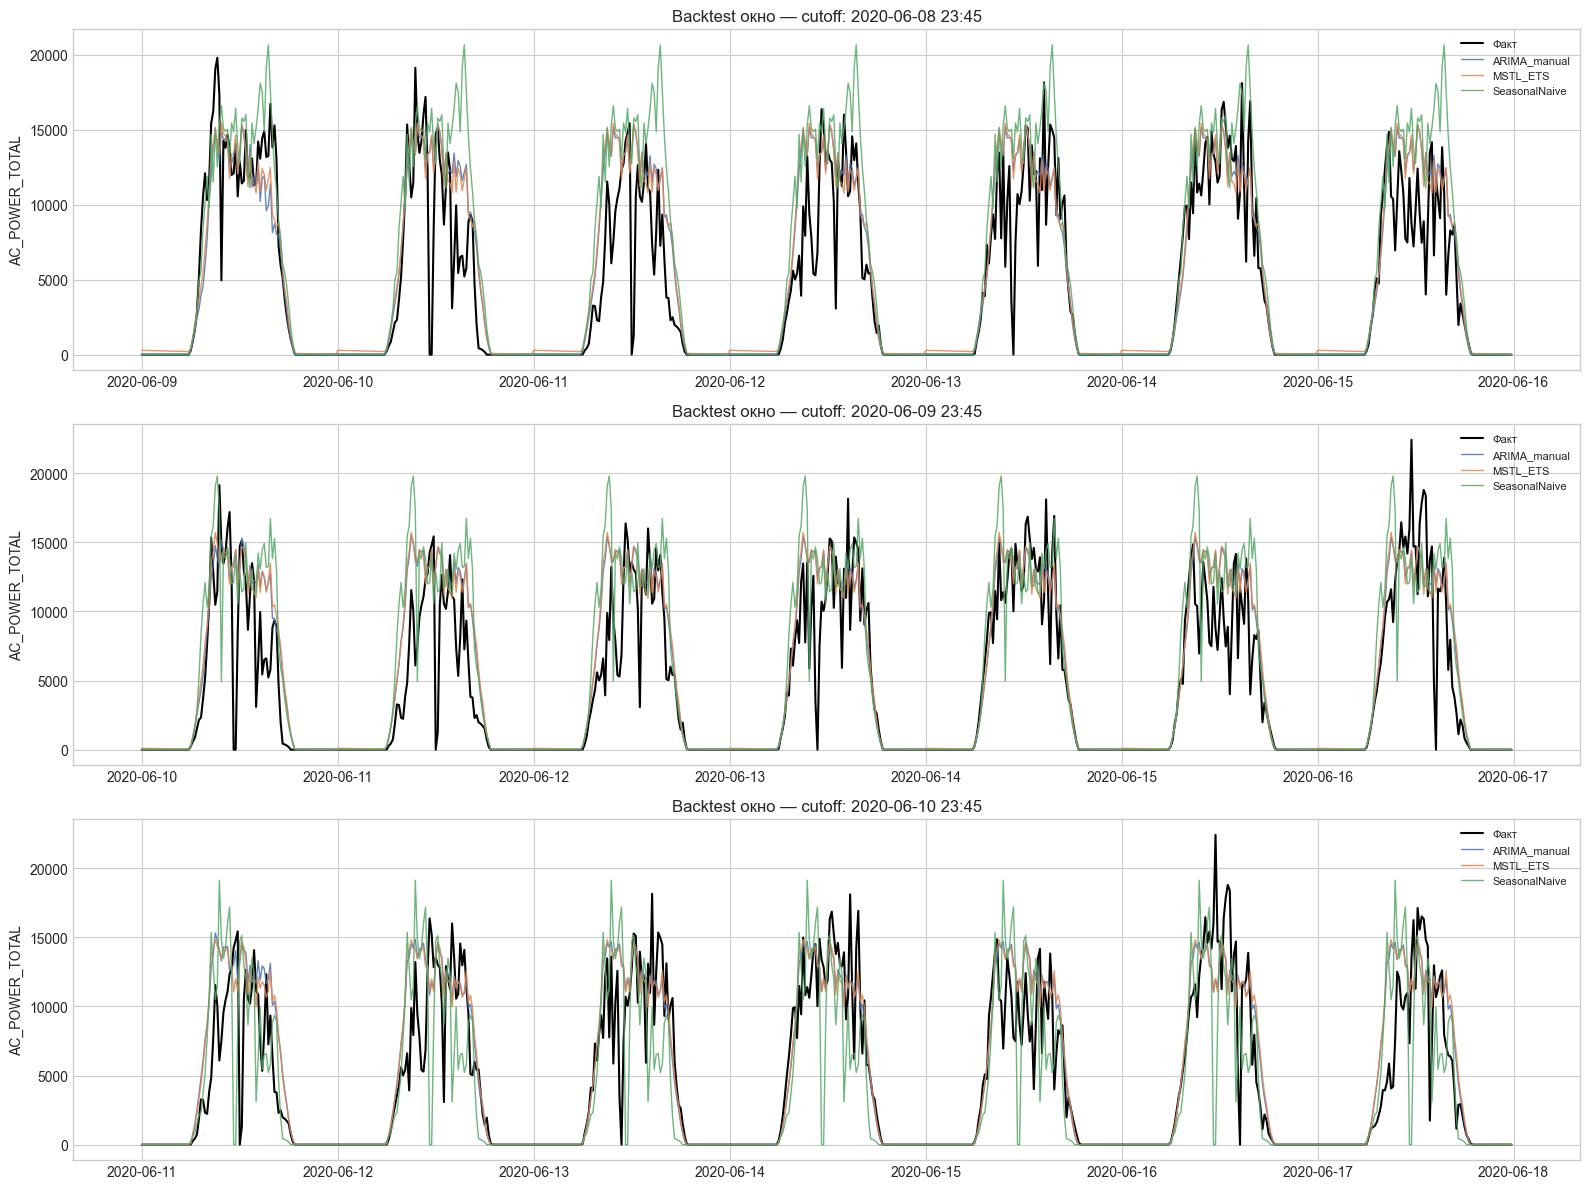

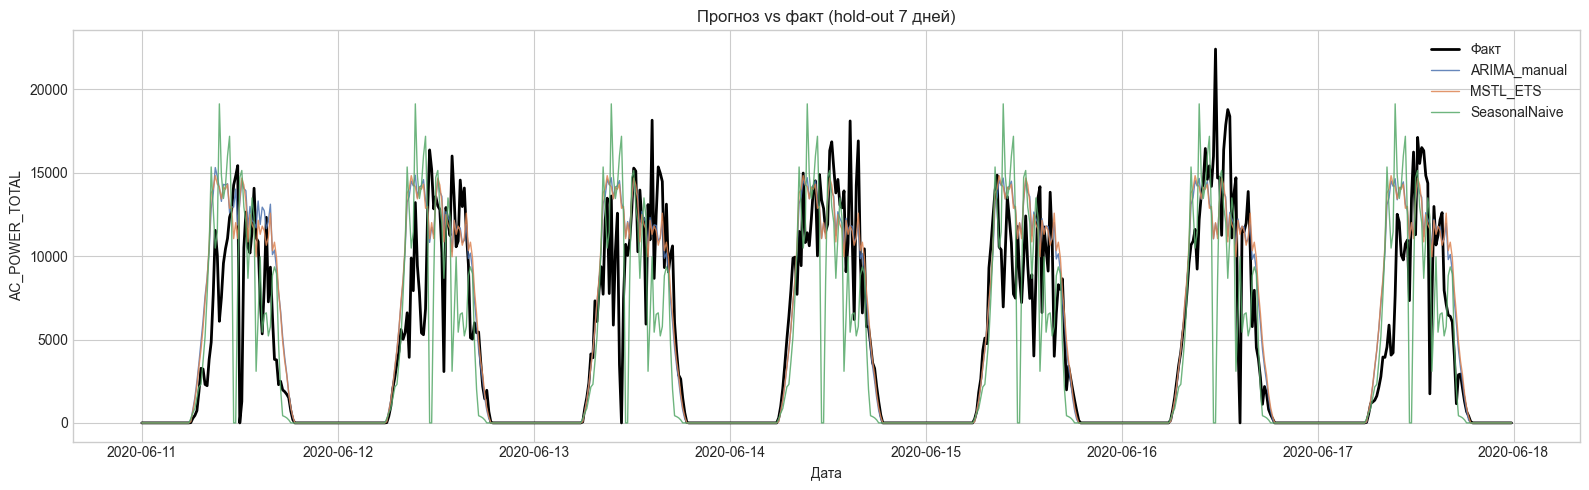

Лучшая модель по RMSE: ARIMA_manual


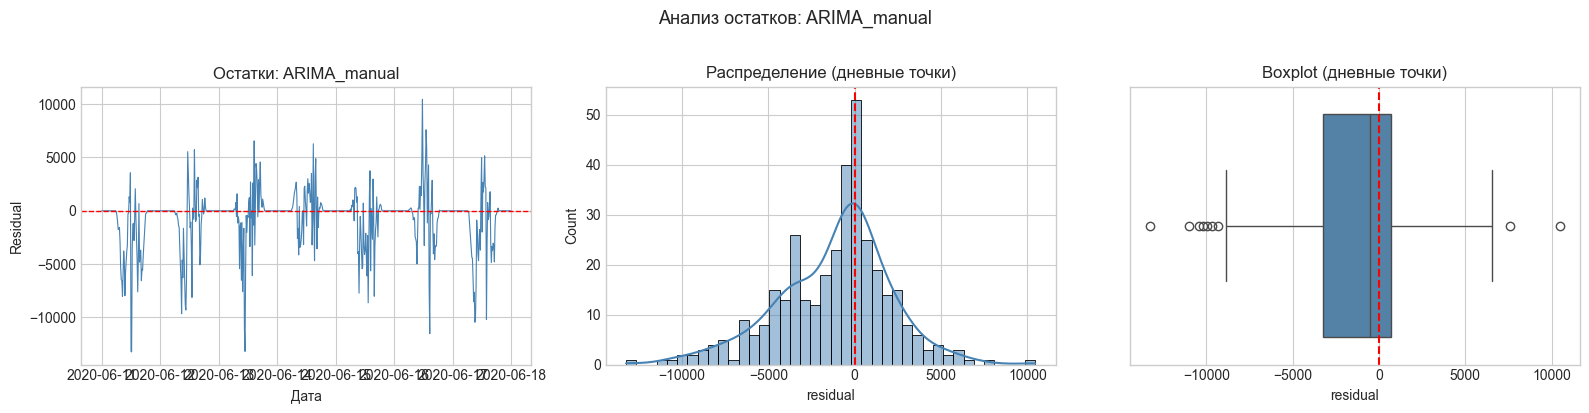


Статистика остатков (дневные точки):
  Mean:     -1177.9  (0 = нет смещения)
  Std:      3294.8
  Skewness: -0.415  (0 = симметрия)
  Kurt:     0.892  (0 = нормальность)


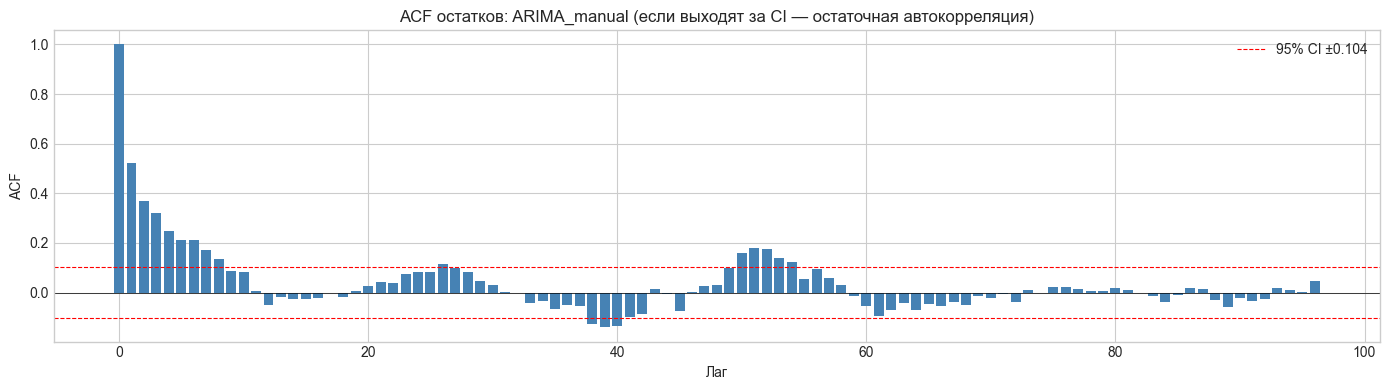

Probabilistic forecast: 3.4 сек


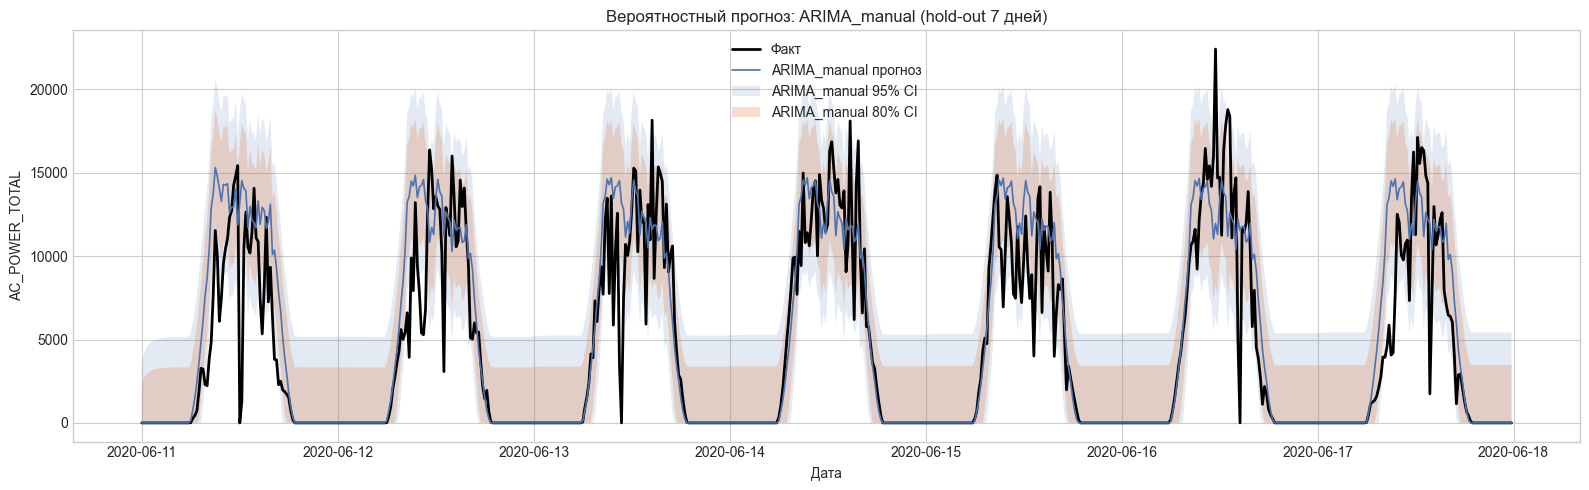


=== Итоговое сравнение статистических моделей ===
        model  MAE_bt  RMSE_bt  sMAPE_bt  MAE_ho  RMSE_ho  sMAPE_ho
 ARIMA_manual  1392.3   2696.9     35.51  1405.0   2687.3     37.15
     MSTL_ETS  1453.0   2724.9     35.73  1431.1   2726.3     36.80
SeasonalNaive  1948.7   3667.1     50.74  2038.6   3903.8     67.31

Выбор: ARIMA_manual
  MAE hold-out:  1405.0
  RMSE hold-out: 2687.3
  sMAPE hold-out: 37.15%

Файлы сохранены в output/task2_*


In [10]:
# %% [markdown]
# Продолжение: cross_validation, анализ остатков, вероятностный прогноз

# %%
# Cross-validation (backtest)
t0 = time.time()
cv_df = sf_obj.cross_validation(
    df=sf_df,
    h=h,
    step_size=season_length,
    n_windows=3,
)
cv_df = cv_df.reset_index()
for name in model_names:
    cv_df[name] = cv_df[name].clip(lower=0)
print(f"Cross-validation: {time.time()-t0:.1f} сек")

# %% [markdown]
# Метрики backtest по каждому окну

# %%
for window, grp in cv_df.groupby("cutoff"):
    print(f"\n--- Cutoff: {window} ---")
    for name in model_names:
        m = compute_metrics(grp["y"].values, grp[name].values, name)
        print(f"  {name:15s} MAE={m['MAE']:>7.1f}  RMSE={m['RMSE']:>7.1f}  sMAPE={m['sMAPE_day']:>6.2f}%")

# Средние по всем окнам
print("\nСредние по backtest:")
bt_df = pd.DataFrame([
    compute_metrics(cv_df["y"].values, cv_df[name].values, name)
    for name in model_names
]).sort_values("RMSE").reset_index(drop=True)
print(bt_df)

# %% [markdown]
# Визуализация backtest по окнам

# %%
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
for ax, (cutoff, grp) in zip(axes, cv_df.groupby("cutoff")):
    ax.plot(grp["ds"], grp["y"], label="Факт", color="black", linewidth=1.5)
    for name in model_names:
        ax.plot(grp["ds"], grp[name], label=name, linewidth=1, alpha=0.85)
    ax.set_title(f"Backtest окно — cutoff: {str(cutoff)[:16]}")
    ax.set_ylabel("AC_POWER_TOTAL")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("output/task2_backtest_windows.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# Визуальное сравнение прогноза и факта (hold-out 7 дней)

# %%
plt.figure(figsize=(16, 5))
plt.plot(test_df["ds"], test_df["y"], label="Факт", linewidth=2, color="black")
for name in model_names:
    plt.plot(fc_df["ds"], fc_df[name], label=name, linewidth=1, alpha=0.85)
plt.title("Прогноз vs факт (hold-out 7 дней)")
plt.xlabel("Дата"); plt.ylabel("AC_POWER_TOTAL")
plt.legend(); plt.tight_layout()
plt.savefig("output/task2_forecast_vs_fact.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# Анализ остатков лучшей модели

# %%
best = holdout_df.iloc[0]["model"]
print(f"Лучшая модель по RMSE: {best}")

res = fc_df[["ds", "y", best]].copy()
res["residual"] = res["y"] - res[best]

# Только дневные точки (ненулевые)
res_day = res[res["y"] > 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(res["ds"], res["residual"], linewidth=0.8, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Остатки: {best}")
axes[0].set_xlabel("Дата"); axes[0].set_ylabel("Residual")

sns.histplot(res_day["residual"], bins=40, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Распределение (дневные точки)")
axes[1].axvline(0, color="red", linestyle="--")

sns.boxplot(x=res_day["residual"], ax=axes[2], color="steelblue")
axes[2].set_title("Boxplot (дневные точки)")
axes[2].axvline(0, color="red", linestyle="--")

plt.suptitle(f"Анализ остатков: {best}", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("output/task2_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nСтатистика остатков (дневные точки):")
print(f"  Mean:     {res_day['residual'].mean():.1f}  (0 = нет смещения)")
print(f"  Std:      {res_day['residual'].std():.1f}")
print(f"  Skewness: {res_day['residual'].skew():.3f}  (0 = симметрия)")
print(f"  Kurt:     {res_day['residual'].kurtosis():.3f}  (0 = нормальность)")

# %% [markdown]
# ACF остатков — проверка на автокорреляцию

# %%
def manual_acf(series, nlags=100):
    y = series.dropna().values - series.dropna().mean()
    return [1.0] + [np.sum(y[lag:] * y[:-lag]) / np.sum(y**2) for lag in range(1, nlags+1)]

resid_values = res_day["residual"]
acf_vals = manual_acf(resid_values, nlags=96)
conf = 1.96 / np.sqrt(len(resid_values))

plt.figure(figsize=(14, 4))
plt.bar(range(len(acf_vals)), acf_vals, color="steelblue", width=0.8)
plt.axhline(conf,  color="red", linestyle="--", linewidth=0.8, label=f"95% CI ±{conf:.3f}")
plt.axhline(-conf, color="red", linestyle="--", linewidth=0.8)
plt.axhline(0, color="black", linewidth=0.5)
plt.title(f"ACF остатков: {best} (если выходят за CI — остаточная автокорреляция)")
plt.xlabel("Лаг"); plt.ylabel("ACF"); plt.legend()
plt.tight_layout()
plt.savefig("output/task2_residuals_acf.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# Вероятностный прогноз с интервалами

# %%
t0 = time.time()
fc_prob = (StatsForecast(models=models, freq=freq, n_jobs=1)
           .forecast(df=train_df, h=h, level=[80, 95])
           .reset_index()
           .merge(test_df, how="left", on=["unique_id", "ds"]))
for name in model_names:
    fc_prob[name] = fc_prob[name].clip(lower=0)
print(f"Probabilistic forecast: {time.time()-t0:.1f} сек")

plt.figure(figsize=(16, 5))
plt.plot(test_df["ds"], test_df["y"], label="Факт", color="black", linewidth=2)
plt.plot(fc_prob["ds"], fc_prob[best], label=f"{best} прогноз", linewidth=1.2)
for lvl, alpha in [(95, 0.15), (80, 0.28)]:
    lo, hi = f"{best}-lo-{lvl}", f"{best}-hi-{lvl}"
    if lo in fc_prob.columns:
        plt.fill_between(fc_prob["ds"], fc_prob[lo].clip(0), fc_prob[hi].clip(0),
                         alpha=alpha, label=f"{best} {lvl}% CI")
plt.title(f"Вероятностный прогноз: {best} (hold-out 7 дней)")
plt.xlabel("Дата"); plt.ylabel("AC_POWER_TOTAL")
plt.legend(); plt.tight_layout()
plt.savefig("output/task2_probabilistic.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# Итоговая сводная таблица

# %%
summary = (
    bt_df
    .rename(columns={"MAE": "MAE_bt", "RMSE": "RMSE_bt", "sMAPE_day": "sMAPE_bt"})
    .merge(
        holdout_df.rename(columns={"MAE": "MAE_ho", "RMSE": "RMSE_ho", "sMAPE_day": "sMAPE_ho"}),
        on="model"
    )
    .sort_values("RMSE_ho")
)

print("\n=== Итоговое сравнение статистических моделей ===")
print(summary.to_string(index=False))
summary.to_csv("output/task2_arima_comparison.csv", index=False)

winner = summary.iloc[0]["model"]
print(f"\nВыбор: {winner}")
print(f"  MAE hold-out:  {summary.iloc[0]['MAE_ho']}")
print(f"  RMSE hold-out: {summary.iloc[0]['RMSE_ho']}")
print(f"  sMAPE hold-out: {summary.iloc[0]['sMAPE_ho']}%")
print(f"\nФайлы сохранены в output/task2_*")

Задача 3

rename_map: {'Ridge': 'Ridge', 'LGBMRegressor': 'LightGBM', 'XGBRegressor': 'XGBoost'}
  unique_id                  ds  Ridge  LightGBM    XGBoost    y
0    plant2 2020-06-11 00:00:00    0.0       0.0  21.939674  0.0
1    plant2 2020-06-11 00:15:00    0.0       0.0  21.939674  0.0
2    plant2 2020-06-11 00:30:00    0.0       0.0  21.939674  0.0
3    plant2 2020-06-11 00:45:00    0.0       0.0  21.939674  0.0
4    plant2 2020-06-11 01:00:00    0.0       0.0  21.939674  0.0
5    plant2 2020-06-11 01:15:00    0.0       0.0  21.939674  0.0
6    plant2 2020-06-11 01:30:00    0.0       0.0  21.939674  0.0
7    plant2 2020-06-11 01:45:00    0.0       0.0  21.939674  0.0
8    plant2 2020-06-11 02:00:00    0.0       0.0  21.939674  0.0
9    plant2 2020-06-11 02:15:00    0.0       0.0  21.939674  0.0
ML метрики (hold-out):
      model     MAE    RMSE  sMAPE_day
0     Ridge  2147.5  3060.1      43.90
1  LightGBM  1629.1  2978.4      41.49
2   XGBoost  1637.2  2894.8      42.43


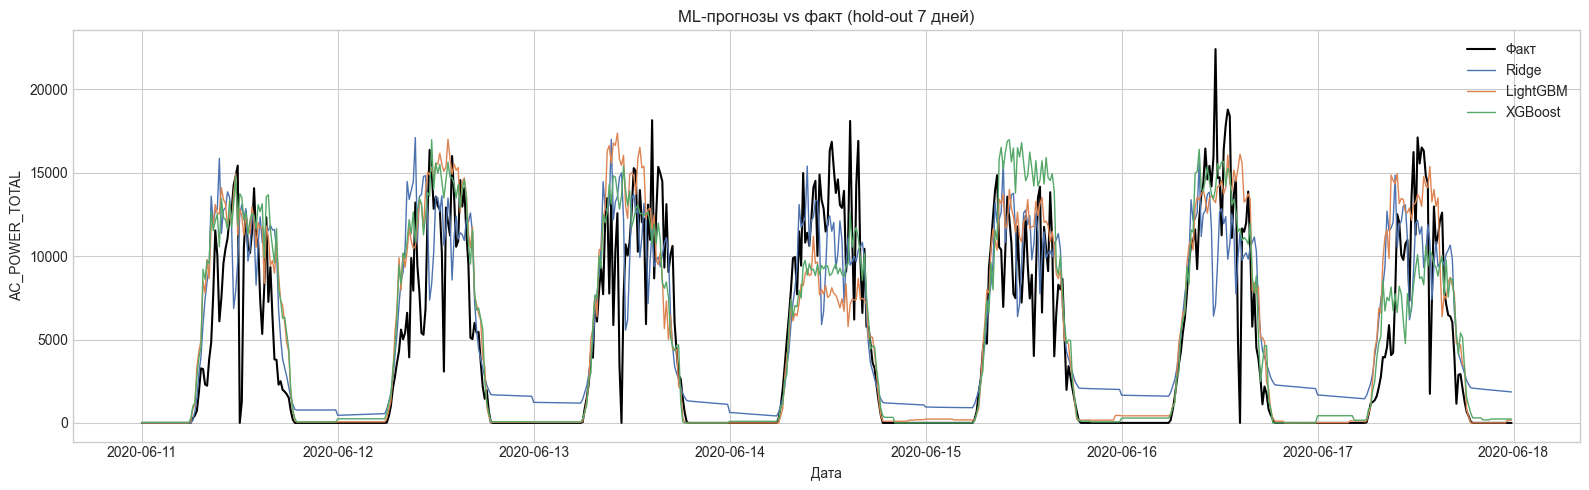

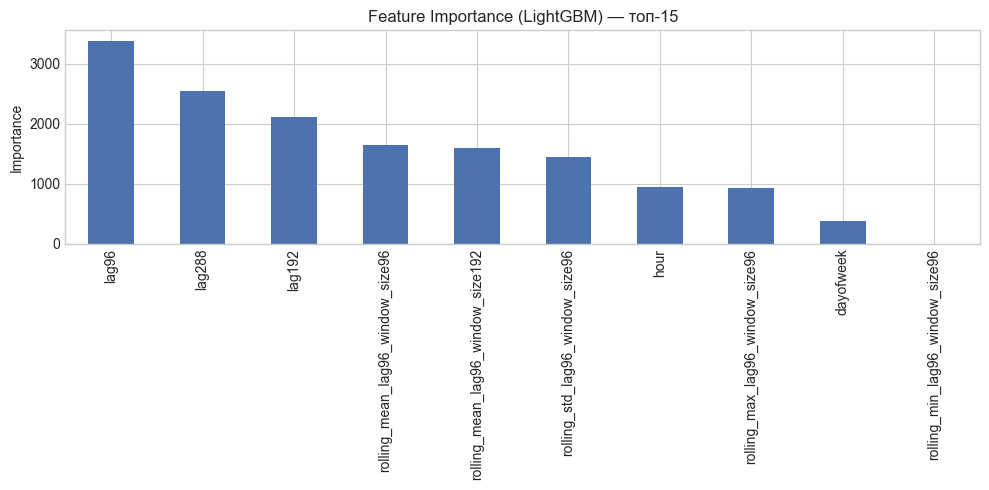

ML Backtest (среднее по окнам):
              MAE     RMSE
model                     
LightGBM  1738.47  3005.50
Ridge     1906.87  2851.37
XGBoost   1750.37  2958.03


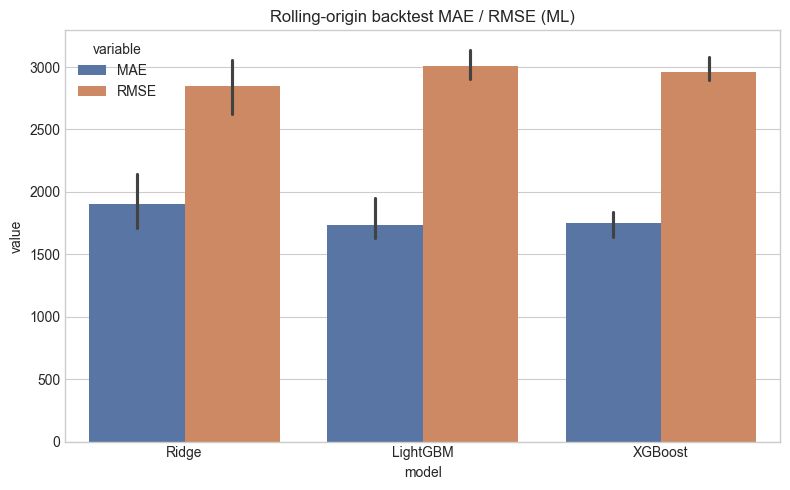

In [12]:
# %% [markdown]
# Исправленный ML-блок: без Differences, с clip(0), корректный feature engineering

# %%
import lightgbm as lgb
import xgboost as xgb
from mlforecast import MLForecast
from window_ops.rolling import rolling_mean, rolling_max, rolling_min, rolling_std
from sklearn.linear_model import Ridge

ml_models_list = [
    Ridge(alpha=1.0),
    lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.03,
        num_leaves=31, min_child_samples=20,
        random_state=42, verbose=-1, n_jobs=1,
    ),
    xgb.XGBRegressor(
        n_estimators=500, learning_rate=0.03,
        max_depth=5, min_child_weight=10,
        random_state=42, verbosity=0, n_jobs=1,
    ),
]

ml_model_names_raw = ["Ridge", "LGBMRegressor", "XGBRegressor"]
ml_model_names     = ["Ridge",  "LightGBM",      "XGBoost"]

mlf = MLForecast(
    models=ml_models_list,
    freq=freq,
    # Лаги: 1, 2, 3 дня назад (96, 192, 288 шагов × 15 мин)
    lags=[96, 192, 288],
    lag_transforms={
        # Rolling по окну 1 день (96 шагов)
        96: [
            (rolling_mean, 96),   # средняя за вчера
            (rolling_mean, 192),  # средняя за 2 дня
            (rolling_max,  96),   # максимум за вчера
            (rolling_min,  96),   # минимум за вчера
            (rolling_std,  96),   # стд за вчера
        ],
    },
    # Временные признаки: час + день недели (ключ для суточного паттерна)
    date_features=["hour", "dayofweek"],
    # БЕЗ target_transforms — Differences ломал восстановление ряда
)

# %% [markdown]
# Обучение и прогноз

# %%
mlf.fit(train_df)
ml_forecasts_raw = mlf.predict(h=h)

# Автоматически строим rename_map
service_cols = {"unique_id", "ds"}
forecast_cols_raw = [c for c in ml_forecasts_raw.columns if c not in service_cols]
rename_map = dict(zip(forecast_cols_raw, ml_model_names))
print("rename_map:", rename_map)

ml_forecasts = ml_forecasts_raw.rename(columns=rename_map)
ml_fc = ml_forecasts.merge(test_df, how="left", on=["unique_id", "ds"])

# Clip: солнечная генерация не может быть отрицательной
for name in ml_model_names:
    ml_fc[name] = ml_fc[name].clip(lower=0)

print(ml_fc.head(10))

# %% [markdown]
# Метрики ML на hold-out

# %%
ml_results = []
for name in ml_model_names:
    ml_results.append(compute_metrics(ml_fc["y"].values, ml_fc[name].values, name))

ml_metrics_df = pd.DataFrame(ml_results)
print("ML метрики (hold-out):")
print(ml_metrics_df)

# %% [markdown]
# Прогноз vs факт

# %%
plt.figure(figsize=(16, 5))
plt.plot(test_df["ds"], test_df["y"], label="Факт", linewidth=1.5, color="black")
for name in ml_model_names:
    plt.plot(ml_fc["ds"], ml_fc[name], label=name, linewidth=1)
plt.title("ML-прогнозы vs факт (hold-out 7 дней)")
plt.xlabel("Дата")
plt.ylabel("AC_POWER_TOTAL")
plt.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# Feature importance LightGBM

# %%
lgbm_key = [k for k in mlf.models_.keys() if "LGBM" in k or "lgbm" in k.lower()][0]
lgbm_fitted = mlf.models_[lgbm_key]

feat_imp = (
    pd.Series(lgbm_fitted.feature_importances_, index=lgbm_fitted.feature_name_)
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind="bar")
plt.title("Feature Importance (LightGBM) — топ-15")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# %% [markdown]
# Rolling backtest для ML (3 окна, без Differences)

# %%
def ml_backtest(sf_df, freq, h, step, n_windows=3):
    results = []
    max_origin = len(sf_df) - h
    origins = [max_origin - step * i for i in range(n_windows - 1, -1, -1)]

    for origin in origins:
        tr = sf_df.iloc[:origin].copy()
        te = sf_df.iloc[origin:origin + h].copy()

        mlf_tmp = MLForecast(
            models=ml_models_list,
            freq=freq,
            lags=[96, 192, 288],
            lag_transforms={
                96: [
                    (rolling_mean, 96),
                    (rolling_mean, 192),
                    (rolling_max,  96),
                    (rolling_min,  96),
                    (rolling_std,  96),
                ],
            },
            date_features=["hour", "dayofweek"],
        )
        mlf_tmp.fit(tr)
        fc_raw = mlf_tmp.predict(h=h)

        fc_cols = [c for c in fc_raw.columns if c not in {"unique_id", "ds"}]
        fc = fc_raw.rename(columns=dict(zip(fc_cols, ml_model_names)))
        fc = fc.merge(te, how="left", on=["unique_id", "ds"])

        for name in ml_model_names:
            fc[name] = fc[name].clip(lower=0)
            m = compute_metrics(fc["y"].values, fc[name].values, name)
            m["origin"] = origin
            results.append(m)

    return pd.DataFrame(results)

ml_bt_df = ml_backtest(sf_df, freq, h=h, step=steps_per_day, n_windows=3)
print("ML Backtest (среднее по окнам):")
print(ml_bt_df.groupby("model")[["MAE", "RMSE"]].mean().round(2))

plt.figure(figsize=(8, 5))
bt_long = ml_bt_df.melt(id_vars=["origin", "model"], value_vars=["MAE", "RMSE"])
sns.barplot(data=bt_long, x="model", y="value", hue="variable")
plt.title("Rolling-origin backtest MAE / RMSE (ML)")
plt.tight_layout()
plt.show()

Задача 4

CFG: {'data_path': 'output/plant2_prepared_timeseries.csv', 'output_dir': 'output', 'freq': '15min', 'season_length': 96, 'test_days': 7, 'n_cv_windows': 3, 'random_seed': 42, 'h': 672, 'cv_step': 96}
OK: 3264 записей, 2020-05-15 00:00:00 → 2020-06-17 23:45:00
Train: 2592, Test: 672, h=672
Hold-out: 3.4 сек
CV: 59.3 сек
MLForecast: 9.9 сек
=== Hold-out ===
        type         model    MAE   RMSE  sMAPE_day
Statistical  ARIMA_manual 1405.0 2687.3      37.15
Statistical      MSTL_ETS 1431.1 2726.3      36.80
         ML         Ridge 1843.4 3128.8      41.07
         ML      LightGBM 1820.3 3258.3      52.88
         ML       XGBoost 2210.7 3604.7      52.11
Statistical SeasonalNaive 2038.6 3903.8      67.31

=== CV ===
        type         model    MAE   RMSE  sMAPE_day
Statistical  ARIMA_manual 1392.3 2696.9      35.51
Statistical      MSTL_ETS 1453.0 2724.9      35.73
         ML         Ridge 1781.0 3124.7      45.30
Statistical SeasonalNaive 1948.7 3667.1      50.74
         ML    

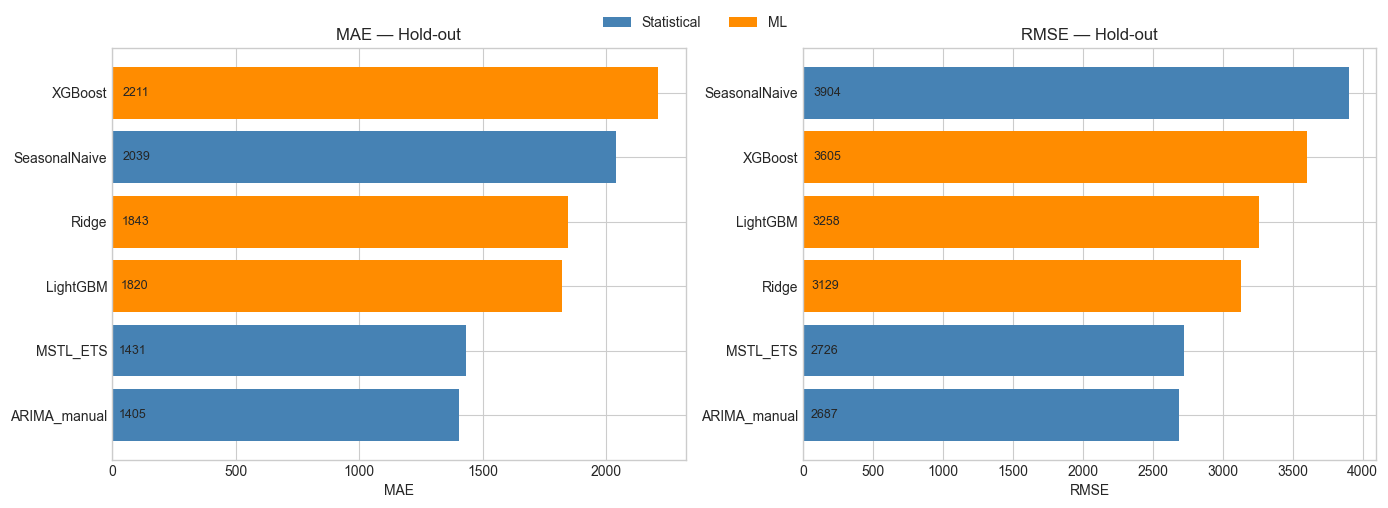

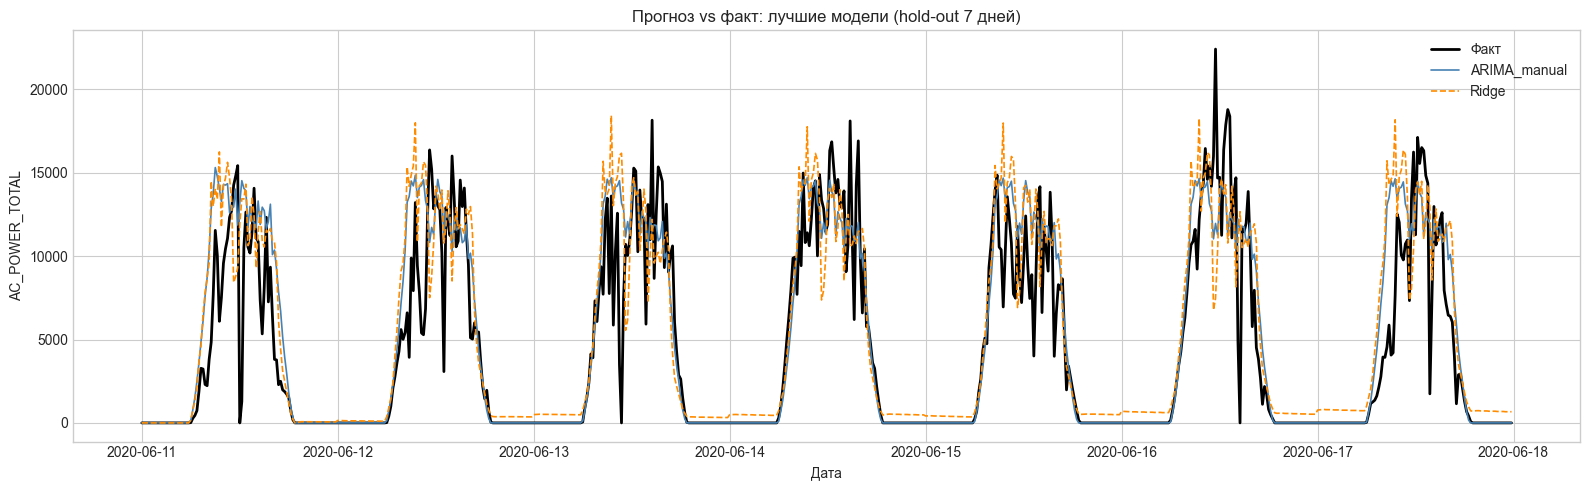

DM ARIMA_manual vs MSTL_ETS: t=-2.542, p=0.0112 → значимо (лучше: MSTL_ETS)
DM ARIMA_manual vs Ridge: t=-6.393, p=0.0000 → значимо (лучше: Ridge)
DM MSTL_ETS vs Ridge: t=-5.836, p=0.0000 → значимо (лучше: Ridge)
  Stat rep 1: 4.60 сек
  Stat rep 2: 4.58 сек
  Stat rep 3: 4.67 сек
  ML   rep 1: 0.31 сек
  ML   rep 2: 0.27 сек
  ML   rep 3: 0.29 сек
             mean   min   max
type                         
ML           0.29  0.27  0.31
Statistical  4.62  4.58  4.67

=== ИТОГ ПАЙПЛАЙНА ===
Лучшая модель:  ARIMA_manual (Statistical)
MAE  hold-out:  1405.0
RMSE hold-out:  2687.3
Артефакты: output/task4_*


In [13]:
# %% [markdown]
# # Задача №4. Производственный пайплайн прогнозирования ВР

# %%
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsforecast import StatsForecast
from statsforecast.models import ARIMA, MSTL, AutoETS, SeasonalNaive
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from window_ops.rolling import rolling_mean, rolling_max
import lightgbm as lgb
import xgboost as xgb

plt.style.use("seaborn-v0_8-whitegrid")

# ── КОНФИГ ──────────────────────────────────────────────────────────────────
CFG = {
    "data_path":     "output/plant2_prepared_timeseries.csv",
    "output_dir":    "output",
    "freq":          "15min",
    "season_length": 96,
    "test_days":     7,
    "n_cv_windows":  3,
    "random_seed":   42,
}
CFG["h"]       = CFG["season_length"] * CFG["test_days"]
CFG["cv_step"] = CFG["season_length"]
Path(CFG["output_dir"]).mkdir(exist_ok=True)
print("CFG:", CFG)

# %% [markdown]
# ## Шаг 1–2. Загрузка и валидация

# %%
def load_and_validate(path):
    df = pd.read_csv(path, parse_dates=["DATE_TIME"])
    assert df.isnull().sum().sum() == 0, "Пропуски!"
    df = df.sort_values("DATE_TIME").reset_index(drop=True)
    steps = df["DATE_TIME"].diff().dropna().unique()
    assert len(steps) == 1 and steps[0] == pd.Timedelta("15min"), "Нерегулярный шаг!"
    print(f"OK: {len(df)} записей, {df['DATE_TIME'].min()} → {df['DATE_TIME'].max()}")
    return df

df_raw = load_and_validate(CFG["data_path"])

# %% [markdown]
# ## Шаг 3. Препроцессинг + Split

# %%
sf_df = (df_raw[["DATE_TIME","AC_POWER_TOTAL"]]
         .rename(columns={"DATE_TIME":"ds","AC_POWER_TOTAL":"y"})
         .assign(unique_id="plant2")[["unique_id","ds","y"]]
         .sort_values("ds").reset_index(drop=True))

n = len(sf_df)
train_sf = sf_df.iloc[:n - CFG["h"]].copy()
test_sf  = sf_df.iloc[n - CFG["h"]:].copy()
print(f"Train: {len(train_sf)}, Test: {len(test_sf)}, h={CFG['h']}")

# %% [markdown]
# ## Шаг 4. Метрика

# %%
def compute_metrics(y_true, y_pred, name):
    yt = np.array(y_true, dtype=float)
    yp = np.array(y_pred, dtype=float).clip(0)
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(np.mean((yt-yp)**2))
    mask = yt > 0
    smape = np.nan
    if mask.sum() > 0:
        a, b = yt[mask], yp[mask]
        d = np.abs(a) + np.abs(b)
        smape = 100*np.mean(np.where(d>0, 2*np.abs(a-b)/d, 0.))
    return {"model":name,"MAE":round(mae,1),"RMSE":round(rmse,1),"sMAPE_day":round(smape,2)}

# %% [markdown]
# ## Шаг 5. StatsForecast

# %%
stat_models = [
    ARIMA(order=(2,1,2), seasonal_order=(1,1,1),
          season_length=CFG["season_length"], alias="ARIMA_manual"),
    MSTL(season_length=CFG["season_length"],
         trend_forecaster=AutoETS(model="ZZN", season_length=1),
         alias="MSTL_ETS"),
    SeasonalNaive(season_length=CFG["season_length"], alias="SeasonalNaive"),
]
stat_names = ["ARIMA_manual", "MSTL_ETS", "SeasonalNaive"]

t0 = time.time()
sf_obj = StatsForecast(models=stat_models, freq=CFG["freq"], n_jobs=1)
fc_stat = sf_obj.forecast(df=train_sf, h=CFG["h"]).reset_index().merge(test_sf, on=["unique_id","ds"])
for m in stat_names: fc_stat[m] = fc_stat[m].clip(0)
print(f"Hold-out: {time.time()-t0:.1f} сек")

t0 = time.time()
cv_stat = sf_obj.cross_validation(df=sf_df, h=CFG["h"],
                                   step_size=CFG["cv_step"],
                                   n_windows=CFG["n_cv_windows"]).reset_index()
for m in stat_names: cv_stat[m] = cv_stat[m].clip(0)
print(f"CV: {time.time()-t0:.1f} сек")

# %% [markdown]
# ## Шаг 6. MLForecast

# %%
ml_models = [
    Ridge(alpha=1.0),
    lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                      random_state=CFG["random_seed"], verbose=-1),
    xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                     random_state=CFG["random_seed"], verbosity=0),
]
ml_names = ["Ridge", "LightGBM", "XGBoost"]

mlf = MLForecast(
    models=ml_models, freq=CFG["freq"],
    lags=[96, 192, 672],
    lag_transforms={96: [(rolling_mean,4),(rolling_max,96)], 192: [(rolling_mean,96)]},
    date_features=["hour","dayofweek"],
    target_transforms=[Differences([CFG["season_length"]])],
)
t0 = time.time()
mlf.fit(train_sf)
fc_ml = mlf.predict(h=CFG["h"]).merge(test_sf, on=["unique_id","ds"])
fc_ml = fc_ml.rename(columns={"LGBMRegressor":"LightGBM","XGBRegressor":"XGBoost"})
ml_names_actual = [c for c in ml_names if c in fc_ml.columns]
for m in ml_names_actual: fc_ml[m] = fc_ml[m].clip(0)
print(f"MLForecast: {time.time()-t0:.1f} сек")

cv_ml = mlf.cross_validation(df=train_sf, h=CFG["h"],
                               step_size=CFG["cv_step"],
                               n_windows=CFG["n_cv_windows"])
cv_ml = cv_ml.rename(columns={"LGBMRegressor":"LightGBM","XGBRegressor":"XGBoost"})
for m in ml_names_actual: cv_ml[m] = cv_ml[m].clip(0)

# %% [markdown]
# ## Шаг 7. Сводная таблица метрик

# %%
rows = []
for name in stat_names:
    m = compute_metrics(fc_stat["y"], fc_stat[name], name)
    m.update({"type":"Statistical","eval":"hold-out"}); rows.append(m)
    m2 = compute_metrics(cv_stat["y"], cv_stat[name], name)
    m2.update({"type":"Statistical","eval":"cv"}); rows.append(m2)

for name in ml_names_actual:
    m = compute_metrics(fc_ml["y"], fc_ml[name], name)
    m.update({"type":"ML","eval":"hold-out"}); rows.append(m)
    m2 = compute_metrics(cv_ml["y"], cv_ml[name], name)
    m2.update({"type":"ML","eval":"cv"}); rows.append(m2)

results_df = pd.DataFrame(rows)
ho = results_df[results_df["eval"]=="hold-out"].sort_values("RMSE").reset_index(drop=True)
cv_m = results_df[results_df["eval"]=="cv"].sort_values("RMSE").reset_index(drop=True)
print("=== Hold-out ===\n", ho[["type","model","MAE","RMSE","sMAPE_day"]].to_string(index=False))
print("\n=== CV ===\n", cv_m[["type","model","MAE","RMSE","sMAPE_day"]].to_string(index=False))
results_df.to_csv("output/task4_all_metrics.csv", index=False)

# %% [markdown]
# ## Шаг 8. Визуализация

# %%
best_stat = ho[ho["type"]=="Statistical"].iloc[0]["model"]
best_ml   = ho[ho["type"]=="ML"].iloc[0]["model"] if ml_names_actual else None

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, metric in zip(axes, ["MAE","RMSE"]):
    data = ho.sort_values(metric)
    colors = ["steelblue" if t=="Statistical" else "darkorange" for t in data["type"]]
    ax.barh(data["model"], data[metric], color=colors)
    ax.set_title(f"{metric} — Hold-out"); ax.set_xlabel(metric)
    for i,(v,_) in enumerate(zip(data[metric],data["model"])):
        ax.text(v*0.02, i, f"{v:.0f}", va="center", fontsize=9)
from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor="steelblue",label="Statistical"),
                    Patch(facecolor="darkorange",label="ML")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5,1.02))
plt.tight_layout()
plt.savefig("output/task4_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(16,5))
plt.plot(test_sf["ds"], test_sf["y"], label="Факт", color="black", linewidth=2)
plt.plot(fc_stat["ds"], fc_stat[best_stat], label=f"{best_stat}", linewidth=1.2, color="steelblue")
if best_ml and best_ml in fc_ml.columns:
    plt.plot(fc_ml["ds"], fc_ml[best_ml], label=f"{best_ml}", linewidth=1.2,
             color="darkorange", linestyle="--")
plt.title("Прогноз vs факт: лучшие модели (hold-out 7 дней)")
plt.xlabel("Дата"); plt.ylabel("AC_POWER_TOTAL")
plt.legend(); plt.tight_layout()
plt.savefig("output/task4_best_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

# %% [markdown]
# ## Шаг 9. Статистическое тестирование (Diebold-Mariano)

# %%
def dm_test(y_true, fc1, fc2, n1, n2):
    e1 = (y_true - fc1)**2
    e2 = (y_true - fc2)**2
    t, p = stats.ttest_1samp(e1 - e2, 0)
    sig = p < 0.05
    print(f"DM {n1} vs {n2}: t={t:.3f}, p={p:.4f} → {'значимо' if sig else 'незначимо'} (лучше: {n1 if t>0 else n2})")
    return {"pair":f"{n1} vs {n2}", "t":round(t,3), "p":round(p,4), "sig":sig}

y_true = fc_stat["y"].values
top3 = ho.head(3)["model"].tolist()
all_fc_vals = {m: fc_stat[m].values for m in stat_names}
all_fc_vals.update({m: fc_ml[m].values for m in ml_names_actual if m in fc_ml.columns})

dm_rows = []
for i in range(len(top3)):
    for j in range(i+1, len(top3)):
        if top3[i] in all_fc_vals and top3[j] in all_fc_vals:
            dm_rows.append(dm_test(y_true, all_fc_vals[top3[i]], all_fc_vals[top3[j]], top3[i], top3[j]))

pd.DataFrame(dm_rows).to_csv("output/task4_dm_test.csv", index=False)

# %% [markdown]
# ## Шаг 10. Тест производительности

# %%
perf = []
for rep in range(3):
    t0 = time.time()
    StatsForecast(models=stat_models, freq=CFG["freq"], n_jobs=1).forecast(df=train_sf, h=96)
    t = time.time()-t0
    perf.append({"type":"Statistical","rep":rep+1,"time_sec":round(t,2)})
    print(f"  Stat rep {rep+1}: {t:.2f} сек")

for rep in range(3):
    t0 = time.time()
    tmp = MLForecast(models=[lgb.LGBMRegressor(n_estimators=100,verbose=-1)],
                     freq=CFG["freq"], lags=[96,192],
                     target_transforms=[Differences([96])])
    tmp.fit(train_sf); tmp.predict(h=96)
    t = time.time()-t0
    perf.append({"type":"ML","rep":rep+1,"time_sec":round(t,2)})
    print(f"  ML   rep {rep+1}: {t:.2f} сек")

perf_df = pd.DataFrame(perf)
print(perf_df.groupby("type")["time_sec"].agg(["mean","min","max"]).round(2))
perf_df.to_csv("output/task4_performance.csv", index=False)

# %% [markdown]
# ## Шаг 11. Сохранение артефактов

# %%
artifact = {
    "config": CFG,
    "best_model":      ho.iloc[0]["model"],
    "best_model_type": ho.iloc[0]["type"],
    "best_MAE":        ho.iloc[0]["MAE"],
    "best_RMSE":       ho.iloc[0]["RMSE"],
    "holdout": ho[["type","model","MAE","RMSE","sMAPE_day"]].to_dict(orient="records"),
    "cv":      cv_m[["type","model","MAE","RMSE","sMAPE_day"]].to_dict(orient="records"),
}
with open("output/task4_pipeline_artifact.json","w",encoding="utf-8") as f:
    json.dump(artifact, f, ensure_ascii=False, indent=2)

print("\n=== ИТОГ ПАЙПЛАЙНА ===")
print(f"Лучшая модель:  {artifact['best_model']} ({artifact['best_model_type']})")
print(f"MAE  hold-out:  {artifact['best_MAE']}")
print(f"RMSE hold-out:  {artifact['best_RMSE']}")
print("Артефакты: output/task4_*")